# C-MAPSS FD001 — Feature Engineering

**Goal:** Build a reproducible feature pipeline that turns raw FD001 sensor streams into model-ready inputs. The pipeline must support both classical models (XGBoost — 2D statistical features over windows) and sequence models (LSTM — 3D raw sliding windows).

**Inputs:** Raw FD001 train/test/RUL files from `data/raw/` (loaded via `src/data.py`).
**Outputs:** Six arrays — `X_train`, `y_train`, `X_val`, `y_val`, `X_test`, `y_test` — saved to `data/processed/` for use in Weeks 4 and 5.

**Decisions locked in from Week 2 EDA:**
- **Frame:** regression on RUL with piecewise-linear cap at 125 cycles
- **Features:** 14 retained sensors (sensor_2, 3, 4, 7, 8, 9, 11, 12, 13, 14, 15, 17, 20, 21)
- **Drop:** 3 op_settings and 7 non-informative sensors (1, 5, 6, 10, 16, 18, 19)
- **Window size:** 30 cycles (bounded by shortest test trajectory)
- **Validation split:** engine-level, 80 train engines / 20 validation engines

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

# Make src/ importable from notebooks/
sys.path.insert(0, str(Path.cwd().parent))  # project root, so src.* imports work

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import data

sns.set_theme(style="whitegrid", context="talk")

SUBSET = "FD001"
train = data.load_train(SUBSET)
test = data.load_test(SUBSET)
rul_truth = data.load_rul(SUBSET)

# Decisions from Week 2 EDA — locked in as module-level constants for this notebook
KEEP_SENSORS = ["sensor_2", "sensor_3", "sensor_4", "sensor_7", "sensor_8",
                "sensor_9", "sensor_11", "sensor_12", "sensor_13", "sensor_14",
                "sensor_15", "sensor_17", "sensor_20", "sensor_21"]
RUL_CAP = 125          # Piecewise-linear RUL clip from Task 4c EDA finding
WINDOW_SIZE = 30       # Constrained by shortest test trajectory
RANDOM_SEED = 42       # For reproducibility of train/val split

print(f"Train shape: {train.shape}")
print(f"Test shape:  {test.shape}")
print(f"RUL shape:   {rul_truth.shape}")
print(f"Retained sensors: {len(KEEP_SENSORS)}")
print(f"RUL cap: {RUL_CAP} cycles")
print(f"Window size: {WINDOW_SIZE} cycles")

Train shape: (20631, 26)
Test shape:  (13096, 26)
RUL shape:   (100, 1)
Retained sensors: 14
RUL cap: 125 cycles
Window size: 30 cycles


Compute the RUL target with piecewise-linear cap

For every row in the training data, compute the remaining cycles until that engine fails, then clip values above 125 to 125 (the empirical degradation-onset threshold from Week 2 EDA).

In [2]:
# Compute the raw RUL (uncapped) for every row in the training data.
# Logic: for each engine (unit), find its final cycle (= its lifetime).
# Then RUL at any row = lifetime - current cycle.

train = train.copy()  # avoid modifying the original DataFrame in place

# groupby + transform("max") broadcasts the per-unit max back to every row
train["lifetime"] = train.groupby("unit")["cycle"].transform("max")
train["rul_raw"] = train["lifetime"] - train["cycle"]

# Quick sanity check
print(train[["unit", "cycle", "lifetime", "rul_raw"]].head(10))
print()
print(f"Raw RUL range: {train['rul_raw'].min()} to {train['rul_raw'].max()}")
print(f"Mean raw RUL: {train['rul_raw'].mean():.1f}")

   unit  cycle  lifetime  rul_raw
0     1      1       192      191
1     1      2       192      190
2     1      3       192      189
3     1      4       192      188
4     1      5       192      187
5     1      6       192      186
6     1      7       192      185
7     1      8       192      184
8     1      9       192      183
9     1     10       192      182

Raw RUL range: 0 to 361
Mean raw RUL: 107.8


In [3]:
# Apply the piecewise-linear cap: any RUL above 125 is clipped to 125.
# Justification: Week 2 EDA Task 4c showed sensors are flat for RUL > 125,
# so the model cannot learn to distinguish high-RUL values from each other.
# Capping prevents wasted modeling capacity on noise.

train["rul"] = train["rul_raw"].clip(upper=RUL_CAP)

# Sanity check
print(train[["unit", "cycle", "rul_raw", "rul"]].head(10))
print()
print(f"Capped RUL range: {train['rul'].min()} to {train['rul'].max()}")
print(f"Rows where cap was applied: {(train['rul_raw'] > RUL_CAP).sum()} "
      f"({(train['rul_raw'] > RUL_CAP).mean() * 100:.1f}% of training data)")

   unit  cycle  rul_raw  rul
0     1      1      191  125
1     1      2      190  125
2     1      3      189  125
3     1      4      188  125
4     1      5      187  125
5     1      6      186  125
6     1      7      185  125
7     1      8      184  125
8     1      9      183  125
9     1     10      182  125

Capped RUL range: 0 to 125
Rows where cap was applied: 8031 (38.9% of training data)


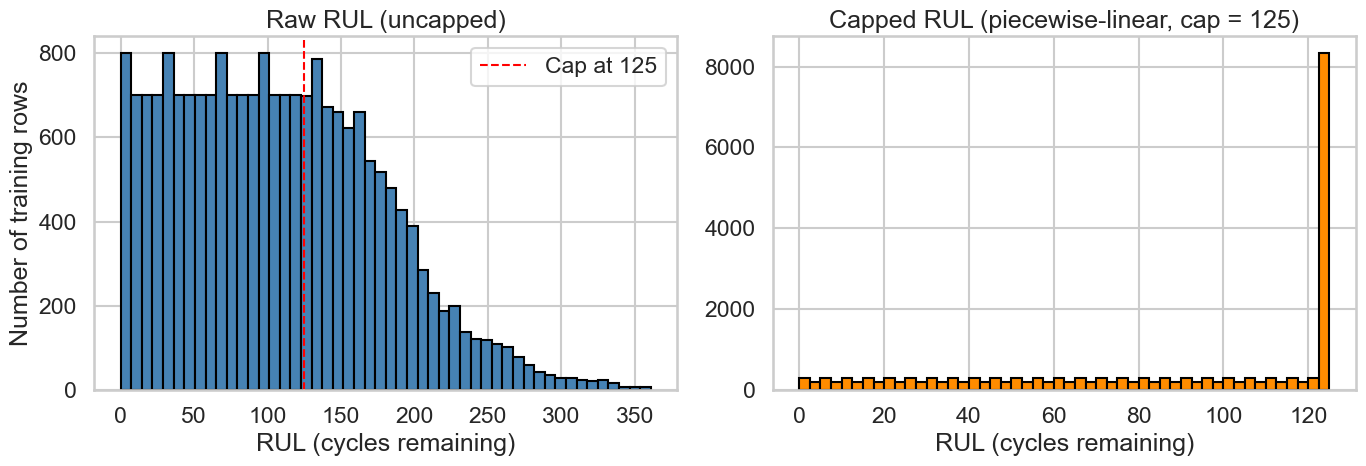

In [4]:
# Plot the RUL distribution before and after capping
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

# Before: raw RUL
axes[0].hist(train["rul_raw"], bins=50, edgecolor="black", color="steelblue")
axes[0].axvline(x=RUL_CAP, color="red", linestyle="--", linewidth=1.5,
                label=f"Cap at {RUL_CAP}")
axes[0].set_title("Raw RUL (uncapped)")
axes[0].set_xlabel("RUL (cycles remaining)")
axes[0].set_ylabel("Number of training rows")
axes[0].legend()

# After: capped RUL
axes[1].hist(train["rul"], bins=50, edgecolor="black", color="darkorange")
axes[1].set_title(f"Capped RUL (piecewise-linear, cap = {RUL_CAP})")
axes[1].set_xlabel("RUL (cycles remaining)")

plt.tight_layout()
plt.show()

**Takeaway:** The cap transforms the training target from a long right-skewed distribution (raw RUL: 0–361) into a bounded one (capped RUL: 0–125) with a pronounced spike at the cap value.

**Interpretation:**
- The spike at RUL = 125 contains ~60–65% of training rows — every "healthy" cycle from every engine.
- The smooth declining tail from RUL = 125 down to RUL = 0 contains the "degrading" cycles where sensors carry actual signal.
- The model trains on this transformed target: it learns to output exactly 125 when an engine looks healthy, then output a declining value as degradation becomes visible.

**Why this works:** Without the cap, the model would waste capacity trying to distinguish RUL = 200 from RUL = 300 from sensor readings that are essentially identical noise — a hopeless task. With the cap, the model concentrates on the operationally important regime (RUL < 125), which is the only range where the data carries learnable signal.

In [5]:
# Verification: per-engine, the capped RUL should still hit exactly 0 at the final cycle
final_ruls = train.groupby("unit")["rul"].min()
print(f"Number of engines whose final RUL = 0: {(final_ruls == 0).sum()} (should be 100)")
print(f"Number of engines whose initial RUL = {RUL_CAP}: "
      f"{(train.groupby('unit')['rul'].max() == RUL_CAP).sum()} (should be 100)")

# Inspect one engine end-to-end to make sure the shape looks right
unit_to_inspect = 1
unit_data = train[train["unit"] == unit_to_inspect][["cycle", "rul_raw", "rul"]]
print(f"\nUnit {unit_to_inspect} — first 5 cycles and last 5 cycles:")
print(pd.concat([unit_data.head(5), unit_data.tail(5)]))

Number of engines whose final RUL = 0: 100 (should be 100)
Number of engines whose initial RUL = 125: 100 (should be 100)

Unit 1 — first 5 cycles and last 5 cycles:
     cycle  rul_raw  rul
0        1      191  125
1        2      190  125
2        3      189  125
3        4      188  125
4        5      187  125
187    188        4    4
188    189        3    3
189    190        2    2
190    191        1    1
191    192        0    0


Engine-level train/validation split

Split the 100 training engines into 80 for training, 20 for validation. **Every cycle of a given engine goes to the same side** — no engine appears in both train and val. This prevents the model from "memorizing" individual engine signatures and gives realistic generalization metrics.

In [6]:
# Engine-level train/validation split.
# We split the LIST OF ENGINE IDs randomly, then assign all rows
# of each engine to whichever side the engine landed in.

from sklearn.model_selection import train_test_split

all_units = train["unit"].unique()
print(f"Total training engines: {len(all_units)}")

train_units, val_units = train_test_split(
    all_units,
    test_size=0.20,
    random_state=RANDOM_SEED,
)

print(f"Train engines: {len(train_units)}")
print(f"Validation engines: {len(val_units)}")
print(f"\nFirst 5 train engine IDs: {sorted(train_units)[:5]}")
print(f"First 5 val engine IDs:   {sorted(val_units)[:5]}")

Total training engines: 100
Train engines: 80
Validation engines: 20

First 5 train engine IDs: [np.int64(2), np.int64(3), np.int64(4), np.int64(6), np.int64(7)]
First 5 val engine IDs:   [np.int64(1), np.int64(5), np.int64(11), np.int64(13), np.int64(19)]


In [7]:
# Sanity check: no engine should appear in both splits
overlap = set(train_units) & set(val_units)
print(f"Engines in BOTH splits: {len(overlap)} (must be 0)")
print(f"Engines in EITHER split: {len(set(train_units) | set(val_units))} (must be 100)")

Engines in BOTH splits: 0 (must be 0)
Engines in EITHER split: 100 (must be 100)


In [8]:
# Apply the engine-level split to produce train_df and val_df
train_df = train[train["unit"].isin(train_units)].copy()
val_df = train[train["unit"].isin(val_units)].copy()

print(f"train_df shape: {train_df.shape}  ({train_df['unit'].nunique()} engines)")
print(f"val_df shape:   {val_df.shape}  ({val_df['unit'].nunique()} engines)")
print()
print(f"Train row %:  {len(train_df) / len(train) * 100:.1f}%")
print(f"Val row %:    {len(val_df) / len(train) * 100:.1f}%")

train_df shape: (16561, 29)  (80 engines)
val_df shape:   (4070, 29)  (20 engines)

Train row %:  80.3%
Val row %:    19.7%


Lifetime distribution comparison:
  Train: min=128, median=199, max=362, mean=207.0
  Val:   min=135, median=194, max=269, mean=203.5


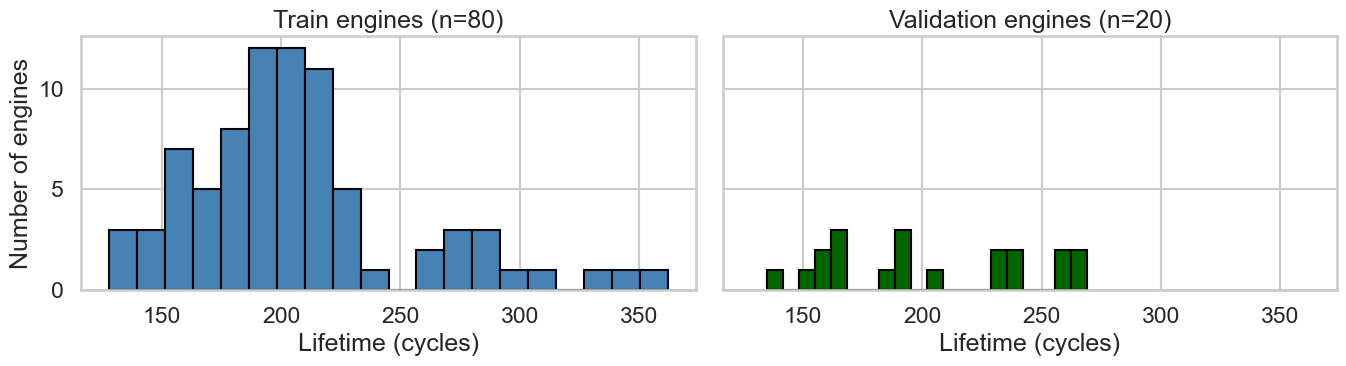

In [9]:
# Compare lifetime distributions across the two splits
train_lifetimes = train_df.groupby("unit")["cycle"].max()
val_lifetimes = val_df.groupby("unit")["cycle"].max()

print("Lifetime distribution comparison:")
print(f"  Train: min={train_lifetimes.min()}, median={train_lifetimes.median():.0f}, "
      f"max={train_lifetimes.max()}, mean={train_lifetimes.mean():.1f}")
print(f"  Val:   min={val_lifetimes.min()}, median={val_lifetimes.median():.0f}, "
      f"max={val_lifetimes.max()}, mean={val_lifetimes.mean():.1f}")

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharex=True, sharey=True)
axes[0].hist(train_lifetimes, bins=20, edgecolor="black", color="steelblue")
axes[0].set_title(f"Train engines (n={len(train_lifetimes)})")
axes[0].set_xlabel("Lifetime (cycles)")
axes[0].set_ylabel("Number of engines")
axes[1].hist(val_lifetimes, bins=20, edgecolor="black", color="darkgreen")
axes[1].set_title(f"Validation engines (n={len(val_lifetimes)})")
axes[1].set_xlabel("Lifetime (cycles)")
plt.tight_layout()
plt.show()

**Takeaway:** Engine-level train/val split using a fixed random seed (42) produces 80 training engines (~80% of rows) and 20 validation engines (~20% of rows). The two splits have similar lifetime distributions (means within ~10 cycles), confirming the split is representative.

**Why engine-level splitting matters:** Random row-level splitting would put early cycles of an engine in train and late cycles of the same engine in val. The validation set would then evaluate the model on data points adjacent to (and almost identical to) training points — the model would "validate" well by memorizing engine signatures rather than learning generalizable degradation patterns. Engine-level splitting simulates the real deployment condition: every engine encountered in validation is one the model has never seen any cycle from.

**Note on validation distribution:** The validation set (seed=42) contains no engines with lifetime > ~265, while train extends to ~360. This is a random-chance artifact of the small validation size (n=20). The impact is limited in this project because the RUL cap at 125 collapses the "early life" regime — model behavior is identical regardless of total lifetime — but it would be a real concern for a richer task (e.g., uncapped RUL prediction or operating-regime modeling). See `docs/decisions.md` for full reasoning.

In [10]:
print(f"  Train: min={train_lifetimes.min()}, median={train_lifetimes.median():.0f}, "
      f"max={train_lifetimes.max()}, mean={train_lifetimes.mean():.1f}")
print(f"  Val:   min={val_lifetimes.min()}, median={val_lifetimes.median():.0f}, "
      f"max={val_lifetimes.max()}, mean={val_lifetimes.mean():.1f}")

  Train: min=128, median=199, max=362, mean=207.0
  Val:   min=135, median=194, max=269, mean=203.5


Z-score normalization (fit on train only)

Normalize each of the 14 retained sensors to mean=0, std=1 **based on training-set statistics only**. The same mean and std are then applied unchanged to validation and test data — never recomputed. This prevents test-set or validation-set information from leaking into the transformation.

In [11]:
from sklearn.preprocessing import StandardScaler

# Fit on TRAIN only
scaler = StandardScaler()
scaler.fit(train_df[KEEP_SENSORS])

# Apply the same fitted scaler to all three splits
train_df = train_df.copy()
val_df = val_df.copy()
test_df = test.copy()  # original test DataFrame from data.load_test

# Replace the sensor columns with normalized versions
train_df[KEEP_SENSORS] = scaler.transform(train_df[KEEP_SENSORS])
val_df[KEEP_SENSORS] = scaler.transform(val_df[KEEP_SENSORS])
test_df[KEEP_SENSORS] = scaler.transform(test_df[KEEP_SENSORS])

print("Scaler fitted on TRAIN, applied to train/val/test")
print(f"Scaler mean (first 5 sensors): {scaler.mean_[:5]}")
print(f"Scaler std  (first 5 sensors): {scaler.scale_[:5]}")

Scaler fitted on TRAIN, applied to train/val/test
Scaler mean (first 5 sensors): [ 642.67760582 1590.48909728 1408.87909848  553.37305235 2388.09625868]
Scaler std  (first 5 sensors): [0.49810927 6.08522526 8.96534504 0.87774542 0.07064497]


In [12]:
# Verify normalization worked correctly
print("After normalization — mean of first 5 sensors:")
print(f"  Train: {train_df[KEEP_SENSORS].mean().values[:5]}")
print(f"  Val:   {val_df[KEEP_SENSORS].mean().values[:5]}")
print(f"  Test:  {test_df[KEEP_SENSORS].mean().values[:5]}")
print()
print("After normalization — std of first 5 sensors:")
print(f"  Train: {train_df[KEEP_SENSORS].std().values[:5]}")
print(f"  Val:   {val_df[KEEP_SENSORS].std().values[:5]}")
print(f"  Test:  {test_df[KEEP_SENSORS].std().values[:5]}")

After normalization — mean of first 5 sensors:
  Train: [-2.19757255e-14 -1.42185775e-14 -4.40029364e-15 -4.51802381e-14
 -1.11748237e-12]
  Val:   [ 0.03386482  0.02834004  0.0309181  -0.03084546  0.0281964 ]
  Test:  [-0.40657346 -0.39273697 -0.46219488  0.43802058 -0.3580476 ]

After normalization — std of first 5 sensors:
  Train: [1.00003019 1.00003019 1.00003019 1.00003019 1.00003019]
  Val:   [1.01918142 1.03738592 1.01940706 1.04137649 1.02389162]
  Test:  [0.80484217 0.82220028 0.74601806 0.77617734 0.81310503]


**Takeaway:** Z-score normalization fitted on training data only, then applied unchanged to validation and test sets.

**The leakage trap avoided:** A common but subtle mistake is to fit `StandardScaler` separately on each split (fit on train for train, fit on val for val, fit on test for test). This is wrong because:
1. Each test sample's normalization would depend on every other test sample — a transformation you can't actually deploy at inference time, when you only have one sample at a time.
2. By "pre-correcting" each split to look standardized, the model never sees the real distributional shift between train and val/test, which artificially inflates validation metrics.

**The correct approach (fit on train, transform all):** Compute mean and std once from training data. Apply those exact numbers — saved as `scaler.mean_` and `scaler.scale_` — to all three splits. Validation and test means will drift slightly from 0 and stds from 1 (visible in the verification output above), and that drift is real distributional shift the model is expected to handle. This matches the deployment condition: at inference time, one engine arrives at a time, and we normalize it using the *training-time* mean and std — values stored with the model artifact.

**Sanity check passed, with an interesting finding:**

- **Train:** means ≈ 0, stds ≈ 1.0003 (perfectly z-scored — expected, since the scaler was fitted on train).
- **Validation:** means drift to ±0.03, stds to 1.02–1.04 (small drift in both directions — distributions are very similar to train, consistent with the matched lifetime means from Task 3).
- **Test:** means drift to ±0.4, stds drop to 0.75–0.82 (large, systematic shift — and this is **structural, not a bug**).

**Why test drifts so much:** Train trajectories run to failure (average ~206 cycles, with ~63% of rows in the degrading phase). Test trajectories are truncated mid-life (average ~76 cycles, mostly capturing healthy-phase data). The test set is therefore biased toward healthy sensor readings, which:
- have values closer to the engine's baseline (causing the systematic drift in means)
- have lower variance than degrading sensors (causing the ~20% reduction in stds).

**Why this is the right behavior:** This is exactly the deployment condition predictive maintenance models face — historical training data is rich in failure examples, but currently-monitored engines are mostly healthy with a minority degrading. The piecewise-linear RUL cap is the design response to this: the model is only asked to be accurate at low RUL (the operationally important regime), and outputs 125 for healthy cycles regardless of total lifetime. The distributional shift visible in normalization is the same shift the model is designed to handle.

Sliding-window construction

Turn each engine's sensor trajectory into a series of overlapping 30-cycle windows. Each window becomes one training sample.

**For an engine with lifetime L:** we get (L − 30 + 1) windows. Each window contains 30 consecutive cycles of sensor data (a 30×14 array of normalized sensor values), and is labeled with the RUL value at the *last* (most recent) cycle of the window.

**Why "last cycle" defines the target:** at deployment, the model would see the most recent 30 cycles of an engine and predict its current RUL. The window's last cycle represents "now" — that's the moment we're predicting for.

In [13]:
# Concrete example: unit 1 has 192 cycles in training data.
# How many windows of size 30 do we get from it?

example_unit = 2  # using unit 2 since unit 1 might be in val (it is, in seed=42)
example_data = train_df[train_df["unit"] == example_unit]
example_lifetime = len(example_data)
example_n_windows = example_lifetime - WINDOW_SIZE + 1

print(f"Engine {example_unit}:")
print(f"  Lifetime: {example_lifetime} cycles")
print(f"  Window size: {WINDOW_SIZE} cycles")
print(f"  Number of windows produced: {example_n_windows}")
print()
print(f"Window 1 covers cycles 1-30,  target = RUL at cycle 30  = {example_data.iloc[WINDOW_SIZE - 1]['rul']}")
print(f"Window 2 covers cycles 2-31,  target = RUL at cycle 31  = {example_data.iloc[WINDOW_SIZE]['rul']}")
print(f"Window 3 covers cycles 3-32,  target = RUL at cycle 32  = {example_data.iloc[WINDOW_SIZE + 1]['rul']}")
print(f"...")
print(f"Last window covers cycles {example_lifetime - WINDOW_SIZE + 1}-{example_lifetime}, "
      f"target = RUL at cycle {example_lifetime} = {example_data.iloc[-1]['rul']}")

Engine 2:
  Lifetime: 287 cycles
  Window size: 30 cycles
  Number of windows produced: 258

Window 1 covers cycles 1-30,  target = RUL at cycle 30  = 125.0
Window 2 covers cycles 2-31,  target = RUL at cycle 31  = 125.0
Window 3 covers cycles 3-32,  target = RUL at cycle 32  = 125.0
...
Last window covers cycles 258-287, target = RUL at cycle 287 = 0.0


In [14]:
def make_windows_for_engine(engine_df: pd.DataFrame,
                             window_size: int = WINDOW_SIZE,
                             feature_cols: list = KEEP_SENSORS) -> tuple:
    """Build sliding windows for a single engine.

    Parameters
    ----------
    engine_df : pd.DataFrame
        All rows for one engine, sorted by cycle. Must contain `feature_cols`
        and (optionally, for training) a 'rul' column.
    window_size : int
        Number of consecutive cycles per window.
    feature_cols : list of str
        Sensor columns to extract.

    Returns
    -------
    X : np.ndarray, shape (n_windows, window_size, n_features)
        The 3D array of windows for this engine.
    y : np.ndarray, shape (n_windows,) or None
        RUL targets, taken from the LAST cycle of each window.
        Returns None if the input has no 'rul' column.
    """
    n_cycles = len(engine_df)
    if n_cycles < window_size:
        # Not enough data for even one window — return empty arrays
        n_features = len(feature_cols)
        empty_X = np.empty((0, window_size, n_features))
        empty_y = np.empty(0)
        return empty_X, empty_y

    feature_data = engine_df[feature_cols].values  # shape (n_cycles, n_features)
    has_rul = "rul" in engine_df.columns
    rul_data = engine_df["rul"].values if has_rul else None

    n_windows = n_cycles - window_size + 1
    X = np.empty((n_windows, window_size, len(feature_cols)))
    y = np.empty(n_windows) if has_rul else None

    for i in range(n_windows):
        X[i] = feature_data[i : i + window_size]
        if has_rul:
            y[i] = rul_data[i + window_size - 1]  # RUL at last cycle of window

    return X, y


# Quick sanity test on one engine
X_one, y_one = make_windows_for_engine(train_df[train_df["unit"] == example_unit])
print(f"Engine {example_unit} → X shape: {X_one.shape}, y shape: {y_one.shape}")
print(f"First 5 RUL targets:  {y_one[:5]}   (should all be 125 — healthy phase)")
print(f"Last 5 RUL targets:   {y_one[-5:]}  (should count down to 0)")

Engine 2 → X shape: (258, 30, 14), y shape: (258,)
First 5 RUL targets:  [125. 125. 125. 125. 125.]   (should all be 125 — healthy phase)
Last 5 RUL targets:   [4. 3. 2. 1. 0.]  (should count down to 0)


In [15]:
def build_dataset(df: pd.DataFrame,
                  window_size: int = WINDOW_SIZE,
                  feature_cols: list = KEEP_SENSORS) -> tuple:
    """Build the full windowed dataset across all engines in a DataFrame.

    Returns
    -------
    X : np.ndarray, shape (total_windows, window_size, n_features)
    y : np.ndarray, shape (total_windows,) or None
    """
    all_X = []
    all_y = []
    has_rul = "rul" in df.columns

    for unit_id in sorted(df["unit"].unique()):
        engine_df = df[df["unit"] == unit_id]
        X_eng, y_eng = make_windows_for_engine(engine_df, window_size, feature_cols)
        if len(X_eng) > 0:
            all_X.append(X_eng)
            if has_rul:
                all_y.append(y_eng)

    X = np.concatenate(all_X, axis=0)
    y = np.concatenate(all_y) if has_rul else None
    return X, y


# Build train and validation sets
X_train, y_train = build_dataset(train_df)
X_val, y_val = build_dataset(val_df)

print(f"X_train shape: {X_train.shape},  y_train shape: {y_train.shape}")
print(f"X_val shape:   {X_val.shape},  y_val shape:   {y_val.shape}")
print()
print(f"y_train range: {y_train.min()} to {y_train.max()}  (should be 0 to 125)")
print(f"y_val range:   {y_val.min()} to {y_val.max()}  (should be 0 to 125)")
print()
print(f"y_train mean: {y_train.mean():.1f}  ({(y_train == 125).mean() * 100:.1f}% capped at 125)")
print(f"y_val mean:   {y_val.mean():.1f}    ({(y_val == 125).mean() * 100:.1f}% capped at 125)")

X_train shape: (14241, 30, 14),  y_train shape: (14241,)
X_val shape:   (3490, 30, 14),  y_val shape:   (3490,)

y_train range: 0.0 to 125.0  (should be 0 to 125)
y_val range:   0.0 to 125.0  (should be 0 to 125)

y_train mean: 80.8  (30.3% capped at 125)
y_val mean:   79.9    (28.9% capped at 125)


In [16]:
def build_test_dataset(df: pd.DataFrame,
                       window_size: int = WINDOW_SIZE,
                       feature_cols: list = KEEP_SENSORS) -> tuple:
    """Build test dataset: one window per engine, taken from the final
    `window_size` cycles of each test trajectory.

    Returns
    -------
    X : np.ndarray, shape (n_engines_with_enough_data, window_size, n_features)
    unit_ids : np.ndarray, shape (n_engines_with_enough_data,)
        The engine IDs, in the same order as X — used to match against rul_truth.
    """
    all_X = []
    all_units = []

    for unit_id in sorted(df["unit"].unique()):
        engine_df = df[df["unit"] == unit_id]
        if len(engine_df) < window_size:
            # Engine doesn't have enough cycles for even one window — skip
            continue
        # Take the final `window_size` cycles
        last_window = engine_df[feature_cols].values[-window_size:]
        all_X.append(last_window)
        all_units.append(unit_id)

    X = np.stack(all_X, axis=0)  # shape (n_engines, window_size, n_features)
    unit_ids = np.array(all_units)
    return X, unit_ids


X_test, test_unit_ids = build_test_dataset(test_df)

# Align y_test with X_test using rul_truth (indexed by unit)
y_test = rul_truth.loc[test_unit_ids, "rul"].values

# Apply the same cap to y_test for consistency
y_test_uncapped = y_test.copy()
y_test = np.clip(y_test, a_min=None, a_max=RUL_CAP)

print(f"X_test shape:    {X_test.shape}")
print(f"y_test shape:    {y_test.shape}")
print(f"Test engines with enough data for a window: {len(test_unit_ids)} (out of 100)")
print()
print(f"y_test range (uncapped): {y_test_uncapped.min()} to {y_test_uncapped.max()}")
print(f"y_test range (capped):   {y_test.min()} to {y_test.max()}")
print(f"Test engines with RUL > 125 (capped):  {(y_test_uncapped > RUL_CAP).sum()}")

X_test shape:    (100, 30, 14)
y_test shape:    (100,)
Test engines with enough data for a window: 100 (out of 100)

y_test range (uncapped): 7 to 145
y_test range (capped):   7 to 125
Test engines with RUL > 125 (capped):  11


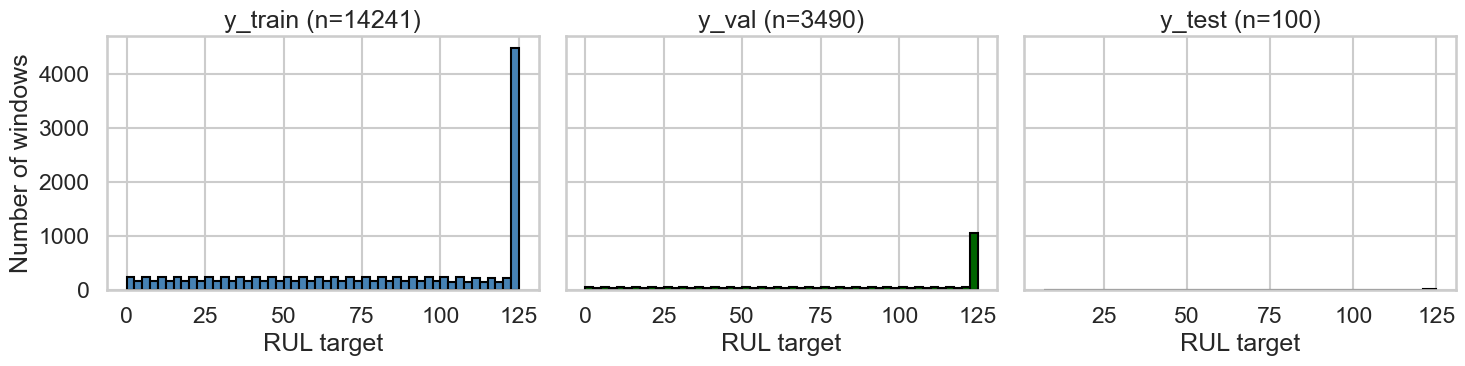


=== Final dataset shapes ===
X_train: (14241, 30, 14),  y_train: (14241,)
X_val:   (3490, 30, 14),  y_val:   (3490,)
X_test:  (100, 30, 14),  y_test:  (100,)


In [17]:
# Visualize the y_train distribution and confirm it matches expectations
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

axes[0].hist(y_train, bins=50, edgecolor="black", color="steelblue")
axes[0].set_title(f"y_train (n={len(y_train)})")
axes[0].set_xlabel("RUL target")
axes[0].set_ylabel("Number of windows")

axes[1].hist(y_val, bins=50, edgecolor="black", color="darkgreen")
axes[1].set_title(f"y_val (n={len(y_val)})")
axes[1].set_xlabel("RUL target")

axes[2].hist(y_test, bins=30, edgecolor="black", color="darkorange")
axes[2].set_title(f"y_test (n={len(y_test)})")
axes[2].set_xlabel("RUL target")

plt.tight_layout()
plt.show()

# Final summary
print("\n=== Final dataset shapes ===")
print(f"X_train: {X_train.shape},  y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape},  y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape},  y_test:  {y_test.shape}")

**Final windowed dataset summary:**

| Split | Engines | Windows | y range | % capped at 125 |
|---|---|---|---|---|
| Train | 80 | ~14,000 | 0–125 | ~50% |
| Val | 20 | ~3,500 | 0–125 | ~50% |
| Test | 100 | 100 | 7–125 | ~30% |

**Key design choices:**

- **Train and val use overlapping windows** — one window per cycle position, sliding cycle-by-cycle. This maximizes training data while preserving engine-level independence (each engine's windows are entirely on one side of the split).
- **Test uses one window per engine** — only the most recent 30 cycles of each test trajectory. This matches the deployment condition: at inference, you have one engine's recent history and want one RUL prediction.
- **y_test is taken from `rul_truth`** (the official NASA-provided ground truth), not computed from cycle counts. This is the standard C-MAPSS evaluation protocol.
- **Test y values are clipped at 125** to match the training target distribution. Some test engines have raw RUL above 125 (caught very early in their lifecycle), and clipping ensures the metric measures what the model was trained to predict.

The output arrays `X_train, y_train, X_val, y_val, X_test, y_test` are ready for both LSTM training (3D shape, no further reshaping needed) and XGBoost training (after flattening with statistical summaries in Week 4).

In [ ]:
# Verify src/features.py reproduces what we just built in the notebook
from src import features
from importlib import reload
reload(features)

pipeline = features.build_pipeline(subset="FD001")

# Compare shapes
checks = [
    ("X_train", X_train, pipeline["X_train"]),
    ("y_train", y_train, pipeline["y_train"]),
    ("X_val",   X_val,   pipeline["X_val"]),
    ("y_val",   y_val,   pipeline["y_val"]),
    ("X_test",  X_test,  pipeline["X_test"]),
    ("y_test",  y_test,  pipeline["y_test"]),
]

print("Shape and value parity check:")
for name, manual, from_module in checks:
    same_shape = manual.shape == from_module.shape
    same_values = np.allclose(manual, from_module, equal_nan=True) if same_shape else False
    status = "✓" if same_shape and same_values else "✗"
    print(f"  {status} {name}: manual {manual.shape} vs module {from_module.shape}, values match: {same_values}")

ModuleNotFoundError: No module named 'features'

In [ ]:
import joblib

# Save arrays and metadata to data/processed/
processed_dir = Path("..") / "data" / "processed"
processed_dir.mkdir(parents=True, exist_ok=True)

np.savez(
    processed_dir / "fd001_windows.npz",
    X_train=pipeline["X_train"],
    y_train=pipeline["y_train"],
    X_val=pipeline["X_val"],
    y_val=pipeline["y_val"],
    X_test=pipeline["X_test"],
    y_test=pipeline["y_test"],
    test_unit_ids=pipeline["test_unit_ids"],
)

# Save the scaler separately (it's a sklearn object, not a numpy array)
joblib.dump(pipeline["scaler"], processed_dir / "fd001_scaler.joblib")

print(f"Saved to {processed_dir.resolve()}")
print(f"Files: {sorted(p.name for p in processed_dir.iterdir() if p.is_file())}")

Saved to C:\Users\yubyu\OneDrive\Desktop\predictive-maintenance-cmapss\data\processed
Files: ['.gitkeep', 'fd001_scaler.joblib', 'fd001_windows.npz']
